In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

--------------------------------------------------------------------------------
Group: read_based
Title: Read-based


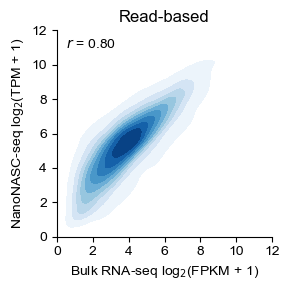

--------------------------------------------------------------------------------
Group: umi_based
Title: UMI-based (reads ≥ 1)


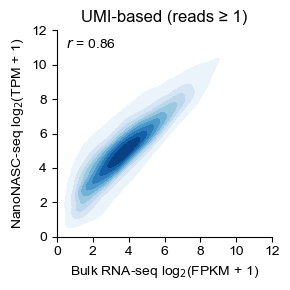

--------------------------------------------------------------------------------
Group: umi_based.mrUMI
Title: UMI-based (reads ≥ 2)


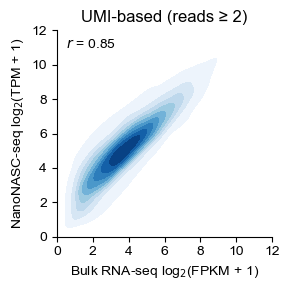

In [6]:
def load_rna_seq(path):
    d = pd.read_csv(path, sep="\t" if path.endswith(".tsv") else ",", index_col=0)
    d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"])]
    d.index = d["GeneID"]
    s = d["FPKM"]
    return s
    
def load_nano_nasc_seq(path):
    d = pd.read_csv(path, sep="\t" if path.endswith(".tsv") else ",", index_col=0)
    s = d.sum(axis=1)
    s = s * 1e6 / sum(s)
    s.name = "TPM"
    return s

def plot_correlation(path1, path2, outfile, title=None):
    s1 = load_rna_seq(path1)
    s2 = load_nano_nasc_seq(path2)
    m = pd.concat([s1, s2], axis=1).fillna(0)
    m = m[(m["FPKM"] >= 1) & (m["TPM"] >= 1)]
    xs = np.log2(m["FPKM"] + 1)
    ys = np.log2(m["TPM"] + 1)
    r = scipy.stats.pearsonr(xs, ys)[0]
    
    plt.figure(figsize=(3, 3))
    plt.title(title)
    # plt.scatter(xs, ys, marker=".", color=plt.colormaps["RdYlBu_r"](0), zorder=1)
    sns.kdeplot(x=xs, y=ys, fill=True, cmap='Blues', cbar=False, alpha=1, zorder=2)
    plt.text(0.5, 11, "$\it{r}$ = %.2f" % r)
    plt.xlim(0, 12)
    plt.ylim(0, 12)
    plt.xticks(np.arange(0, 13, 2))
    plt.yticks(np.arange(0, 13, 2))
    plt.xlabel("Bulk RNA-seq log$_2$(FPKM + 1)")
    plt.ylabel("NanoNASC-seq log$_2$(TPM + 1)")
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    # plt.savefig(outfile)
    plt.show()
    plt.close()

groups = ["read_based", "umi_based", "umi_based.mrUMI"]
titles = ["Read-based", "UMI-based (reads ≥ 1)", "UMI-based (reads ≥ 2)"]
for group, title in zip(groups, titles):
    print("-" * 80)
    print("Group:", group)
    print("Title:", title)
    path1 = "../../../3_RNAseq_ActD/results/3_expression/1_fpkm/20221128_K562_Actd_0h_rep1.human.tsv"
    path2 = "results/matrix/K562.s4U_0uM_180min.%s.csv" % group
    outfile = "figures/correlation.nanonascseq_vs_rnaseq.scatter.%s.pdf" % group
    plot_correlation(path1, path2, outfile, title)